<font size="+3">AF3 benchmark on TCR:epitope interactions</font> <br>
-> full MHC pipeline

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from sklearn.metrics import roc_curve, roc_auc_score
import pickle

import math
from functools import reduce
import re

from Bio.SeqUtils import seq1
from scipy.stats import spearmanr

from sklearn.decomposition import PCA
from Bio.PDB import MMCIFParser, PDBParser, PDBIO, MMCIFIO, Superimposer

# AF3 input

/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_12266/471088666.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_pos_sub = (df_pos.groupby('Epitope', group_keys=False).apply(lambda x: x.sample(n=min(len(x), 1000), random_state=42)))
/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_12266/471088666.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_neg_sub = (df_neg.groupby('E

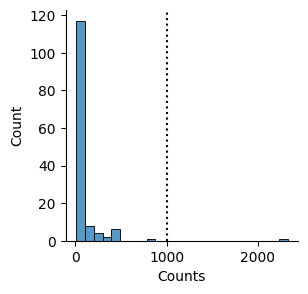

In [6]:
topdir = '../260330_af3_benchmark/Supplementary_Tables'


df = pd.read_csv(f'{topdir}/Supplementary_Table_1.csv')
df = df.drop(columns=['data_usage', 'CV_id'])
df = df.drop_duplicates()

df_pos = df[(df['dataset_source'] == 'Public Paired Data') & (df['Label'] == 1)]
df_neg = df[(df['dataset_source'] == 'Public TCRs with undetermined specificities') & (df['Label'] == 0)]

counts = df_pos['Epitope'].value_counts().reset_index()
counts.columns = ['Epitope', 'Counts']

fig, ax = plt.subplots(1,1,figsize=(3,3))
sns.histplot(data=counts, x='Counts', ax=ax)
ax.axvline(1000, color='black', linestyle=':')
sns.despine()

# subsample positives n > 1000
df_pos_sub = (df_pos.groupby('Epitope', group_keys=False).apply(lambda x: x.sample(n=min(len(x), 1000), random_state=42)))
df_pos_sub.to_csv('positives.csv', index=False)

# how many positives per epitope after subsampling
pos_counts = df_pos_sub['Epitope'].value_counts()

# sample matching number of negatives per epitope
df_neg_sub = (df_neg.groupby('Epitope', group_keys=False).apply(lambda x: x.sample(n=min(len(x), pos_counts.get(x.name, 0)), random_state=42)).reset_index(drop=True))
df_neg_sub.to_csv('negatives.csv', index=False)

In [12]:
topdir = 'class_I'
os.makedirs(topdir, exist_ok=True)

batches = ['positives', 'negatives']
exclude_mhc = ['DRB10101', 'DRB10701', 'DRB11501', 'na']

for batch in batches:
    ndir = f'{topdir}/{batch}'
    os.makedirs(ndir, exist_ok=True)
    df = pd.read_csv(f'{batch}.csv')
    df = df.drop(columns=['Label', 'dataset_source'])
    df['peptide'] = df['Epitope'].str.split('_').str[1]
    df['MHC'] = df['Epitope'].str.split('_').str[0]
    
    # exclude unclear mhcs
    df = df[~df['MHC'].isin(exclude_mhc)]

    # split alpha/beta if present
    mhc_split = df['MHC'].str.split('-', n=1, expand=True)

    # first allele always exists
    df['MHC_allele_a'] = 'HLA_' + mhc_split[0]

    # second allele only exists for entries with '-'
    df['MHC_allele_b'] = mhc_split[1]
    df['MHC_allele_b'] = 'HLA_' + df['MHC_allele_b'].fillna('NA')
    df.loc[mhc_split[1].isna(), 'MHC_allele_b'] = 'NA'
    df = df.drop(columns=['Epitope', 'MHC'])

    tcr_ids = np.array([f'tcr_{i+1:05d}' for i in range(len(df))])
    df.insert(0, 'id', tcr_ids)

    # for now only class I
    df = df[df['MHC_allele_b'] == 'NA']
    df = df.drop(columns=['MHC_allele_b'])
    print(np.unique(df['MHC_allele_a']))
    df.to_csv(f'{ndir}/AF3_class_I.csv', index=False)
    print(len(df))

['HLA_A0101' 'HLA_A0201' 'HLA_A0301' 'HLA_A1101' 'HLA_A2402' 'HLA_A3002'
 'HLA_A6801' 'HLA_B0702' 'HLA_B0801' 'HLA_B1501' 'HLA_B3501' 'HLA_B3701'
 'HLA_B4001' 'HLA_B4402' 'HLA_B5101' 'HLA_B5701' 'HLA_E0103']
9375
['HLA_A0101' 'HLA_A0201' 'HLA_A0301' 'HLA_A1101' 'HLA_A2402' 'HLA_A3002'
 'HLA_A6801' 'HLA_B0702' 'HLA_B0801' 'HLA_B1501' 'HLA_B3501' 'HLA_B3701'
 'HLA_B4001' 'HLA_B4402' 'HLA_B5101' 'HLA_B5701' 'HLA_E0103']
9375


In [13]:
topdir = 'class_II'
os.makedirs(topdir, exist_ok=True)

batches = ['positives', 'negatives']
weirdos = ['DRB10101', 'DRB10701', 'DRB11501']

for batch in batches:
    ndir = f'{topdir}/{batch}'
    os.makedirs(ndir, exist_ok=True)
    df = pd.read_csv(f'{batch}.csv')
    df = df.drop(columns=['Label', 'dataset_source'])
    df['peptide'] = df['Epitope'].str.split('_').str[1]
    df['MHC'] = df['Epitope'].str.split('_').str[0]

    # exclude unclear mhcs / class I
    df = df[~(df['MHC'] == 'na')]
    df = df[df['MHC'].str.startswith('D')]

    # split alpha/beta if present
    mhc_split = df['MHC'].str.split('-', n=1, expand=True)

    # mask for rows with two alleles
    has_two = mhc_split[1].notna()

    # mask for weird single-chain cases
    is_weirdo = mhc_split[0].isin(weirdos)

    # initialize columns
    df['MHC_allele_a'] = None
    df['MHC_allele_b'] = None

    # Case 1: two alleles
    df.loc[has_two, 'MHC_allele_a'] = 'HLA_' + mhc_split[0]
    df.loc[has_two, 'MHC_allele_b'] = 'HLA_' + mhc_split[1]

    # Case 2: weird single allele (e.g. DRB only → pair with DRA)
    df.loc[~has_two & is_weirdo, 'MHC_allele_a'] = 'HLA_DRA_01_01'
    df.loc[~has_two & is_weirdo, 'MHC_allele_b'] = 'HLA_' + mhc_split[0]

    def format_hla(x):
        if pd.isna(x):
            return x
        return re.sub(r'(\d{1,})(\d{2})(\d{2})$', r'\1_\2_\3', x)

    df['MHC_allele_a'] = df['MHC_allele_a'].apply(format_hla)
    df['MHC_allele_b'] = df['MHC_allele_b'].apply(format_hla)

    print(np.unique(df['MHC_allele_a']))
    print(np.unique(df['MHC_allele_b']))

    df = df.drop(columns=['Epitope', 'MHC'])

    tcr_ids = np.array([f'tcr_{i+1:05d}' for i in range(len(df))])
    df.insert(0, 'id', tcr_ids)

    df.to_csv(f'{ndir}/AF3_class_II.csv', index=False)
    print(len(df))

['HLA_DPA1_01_03' 'HLA_DQA1_01_02' 'HLA_DQA1_03_01' 'HLA_DQA1_05_01'
 'HLA_DRA_01_01']
['HLA_DPB1_04_01' 'HLA_DQB1_02_01' 'HLA_DQB1_03_02' 'HLA_DQB1_06_02'
 'HLA_DQB1_06_03' 'HLA_DRB1_01_01' 'HLA_DRB1_07_01' 'HLA_DRB1_15_01']
1006
['HLA_DPA1_01_03' 'HLA_DQA1_01_02' 'HLA_DQA1_03_01' 'HLA_DQA1_05_01'
 'HLA_DRA_01_01']
['HLA_DPB1_04_01' 'HLA_DQB1_02_01' 'HLA_DQB1_03_02' 'HLA_DQB1_06_02'
 'HLA_DQB1_06_03' 'HLA_DRB1_01_01' 'HLA_DRB1_07_01' 'HLA_DRB1_15_01']
1006


# Analyze AF3 output

In [2]:
mhcs = ['class_I', 'class_II']
batches = ['positives', 'negatives']

for mhc in mhcs:
    lst = []
    for batch in batches:
        if mhc == 'class_I':
            df_input = pd.read_csv(f'{mhc}/{batch}/AF3_{mhc}_input.txt', sep='\t')[['id', 'peptide', 'MHC_allele_a']]
            df_input['epitope'] = df_input['MHC_allele_a'].str[4:] + '_' + df_input['peptide']
        else:
            df_input = pd.read_csv(f'{mhc}/{batch}/AF3_{mhc}_input.txt', sep='\t')[['id', 'peptide', 'MHC_allele_a', 'MHC_allele_b']]
            df_input["MHC_allele_a"] = df_input["MHC_allele_a"].str.replace("_", "", regex=False)
            df_input["MHC_allele_b"] = df_input["MHC_allele_b"].str.replace("_", "", regex=False)
            df_input['epitope'] = df_input['MHC_allele_a'].str[3:] + '-' + df_input['MHC_allele_b'].str[3:] + '_' + df_input['peptide']

        df_output = pd.read_csv(f'{mhc}/{batch}/AF3_{mhc}_output.txt', sep='\t')[['id', 'AF3_iptm_pair_mean']]
        
        df = pd.merge(df_input, df_output, on='id')
        df['batch'] = batch
        lst.append(df)

    df = pd.concat(lst)
    df.to_csv(f'AF3_{mhc}_output.csv', index=False)
    print(df.head())

          id    peptide MHC_allele_a          epitope  AF3_iptm_pair_mean  \
0  tcr_00001  ATDALMTGF    HLA_A0101  A0101_ATDALMTGF              0.4675   
1  tcr_00002  ATDALMTGF    HLA_A0101  A0101_ATDALMTGF              0.5100   
2  tcr_00003  ATDALMTGF    HLA_A0101  A0101_ATDALMTGF              0.6700   
3  tcr_00004  ATDALMTGF    HLA_A0101  A0101_ATDALMTGF              0.8725   
4  tcr_00005  ATDALMTGF    HLA_A0101  A0101_ATDALMTGF              0.3225   

       batch  
0  positives  
1  positives  
2  positives  
3  positives  
4  positives  
          id         peptide MHC_allele_a MHC_allele_b  \
0  tcr_00001  TFEYVSQPFLMDLE  HLADPA10103  HLADPB10401   
1  tcr_00002  TFEYVSQPFLMDLE  HLADPA10103  HLADPB10401   
2  tcr_00003  TFEYVSQPFLMDLE  HLADPA10103  HLADPB10401   
3  tcr_00004  TFEYVSQPFLMDLE  HLADPA10103  HLADPB10401   
4  tcr_00005  TFEYVSQPFLMDLE  HLADPA10103  HLADPB10401   

                            epitope  AF3_iptm_pair_mean      batch  
0  DPA10103-DPB10401_TFEYVSQP

            epitope  n_samples  n_samples_iptm_0.5  n_samples_iptm_0.8  \
0   A0101_ATDALMTGF        129                  75                  30   
1   A0101_CTELKLSDY        124                  61                   9   
2  A0101_FTDALGIDEY         12                  10                   5   
3   A0101_FTSDYYQLY         44                  13                   3   
4   A0101_HSNLNDATY         26                  12                   1   

        auc     auc01  
0  0.711766  0.620025  
1  0.746553  0.623761  
2  0.829861  0.641813  
3  0.690539  0.574942  
4  0.745562  0.509499  
                             epitope  n_samples  n_samples_iptm_0.5  \
0   DPA10103-DPB10401_TFEYVSQPFLMDLE        784                 211   
1  DQA10102-DQB10602_AMERNAGSGIIISDT         10                   9   
2    DQA10102-DQB10602_ERNAGSGIIISDT         10                   8   
3  DQA10102-DQB10602_GTRVIRDMTLHSAPS         47                  24   
4  DQA10102-DQB10603_PNANPNVDPNANPNV         10         

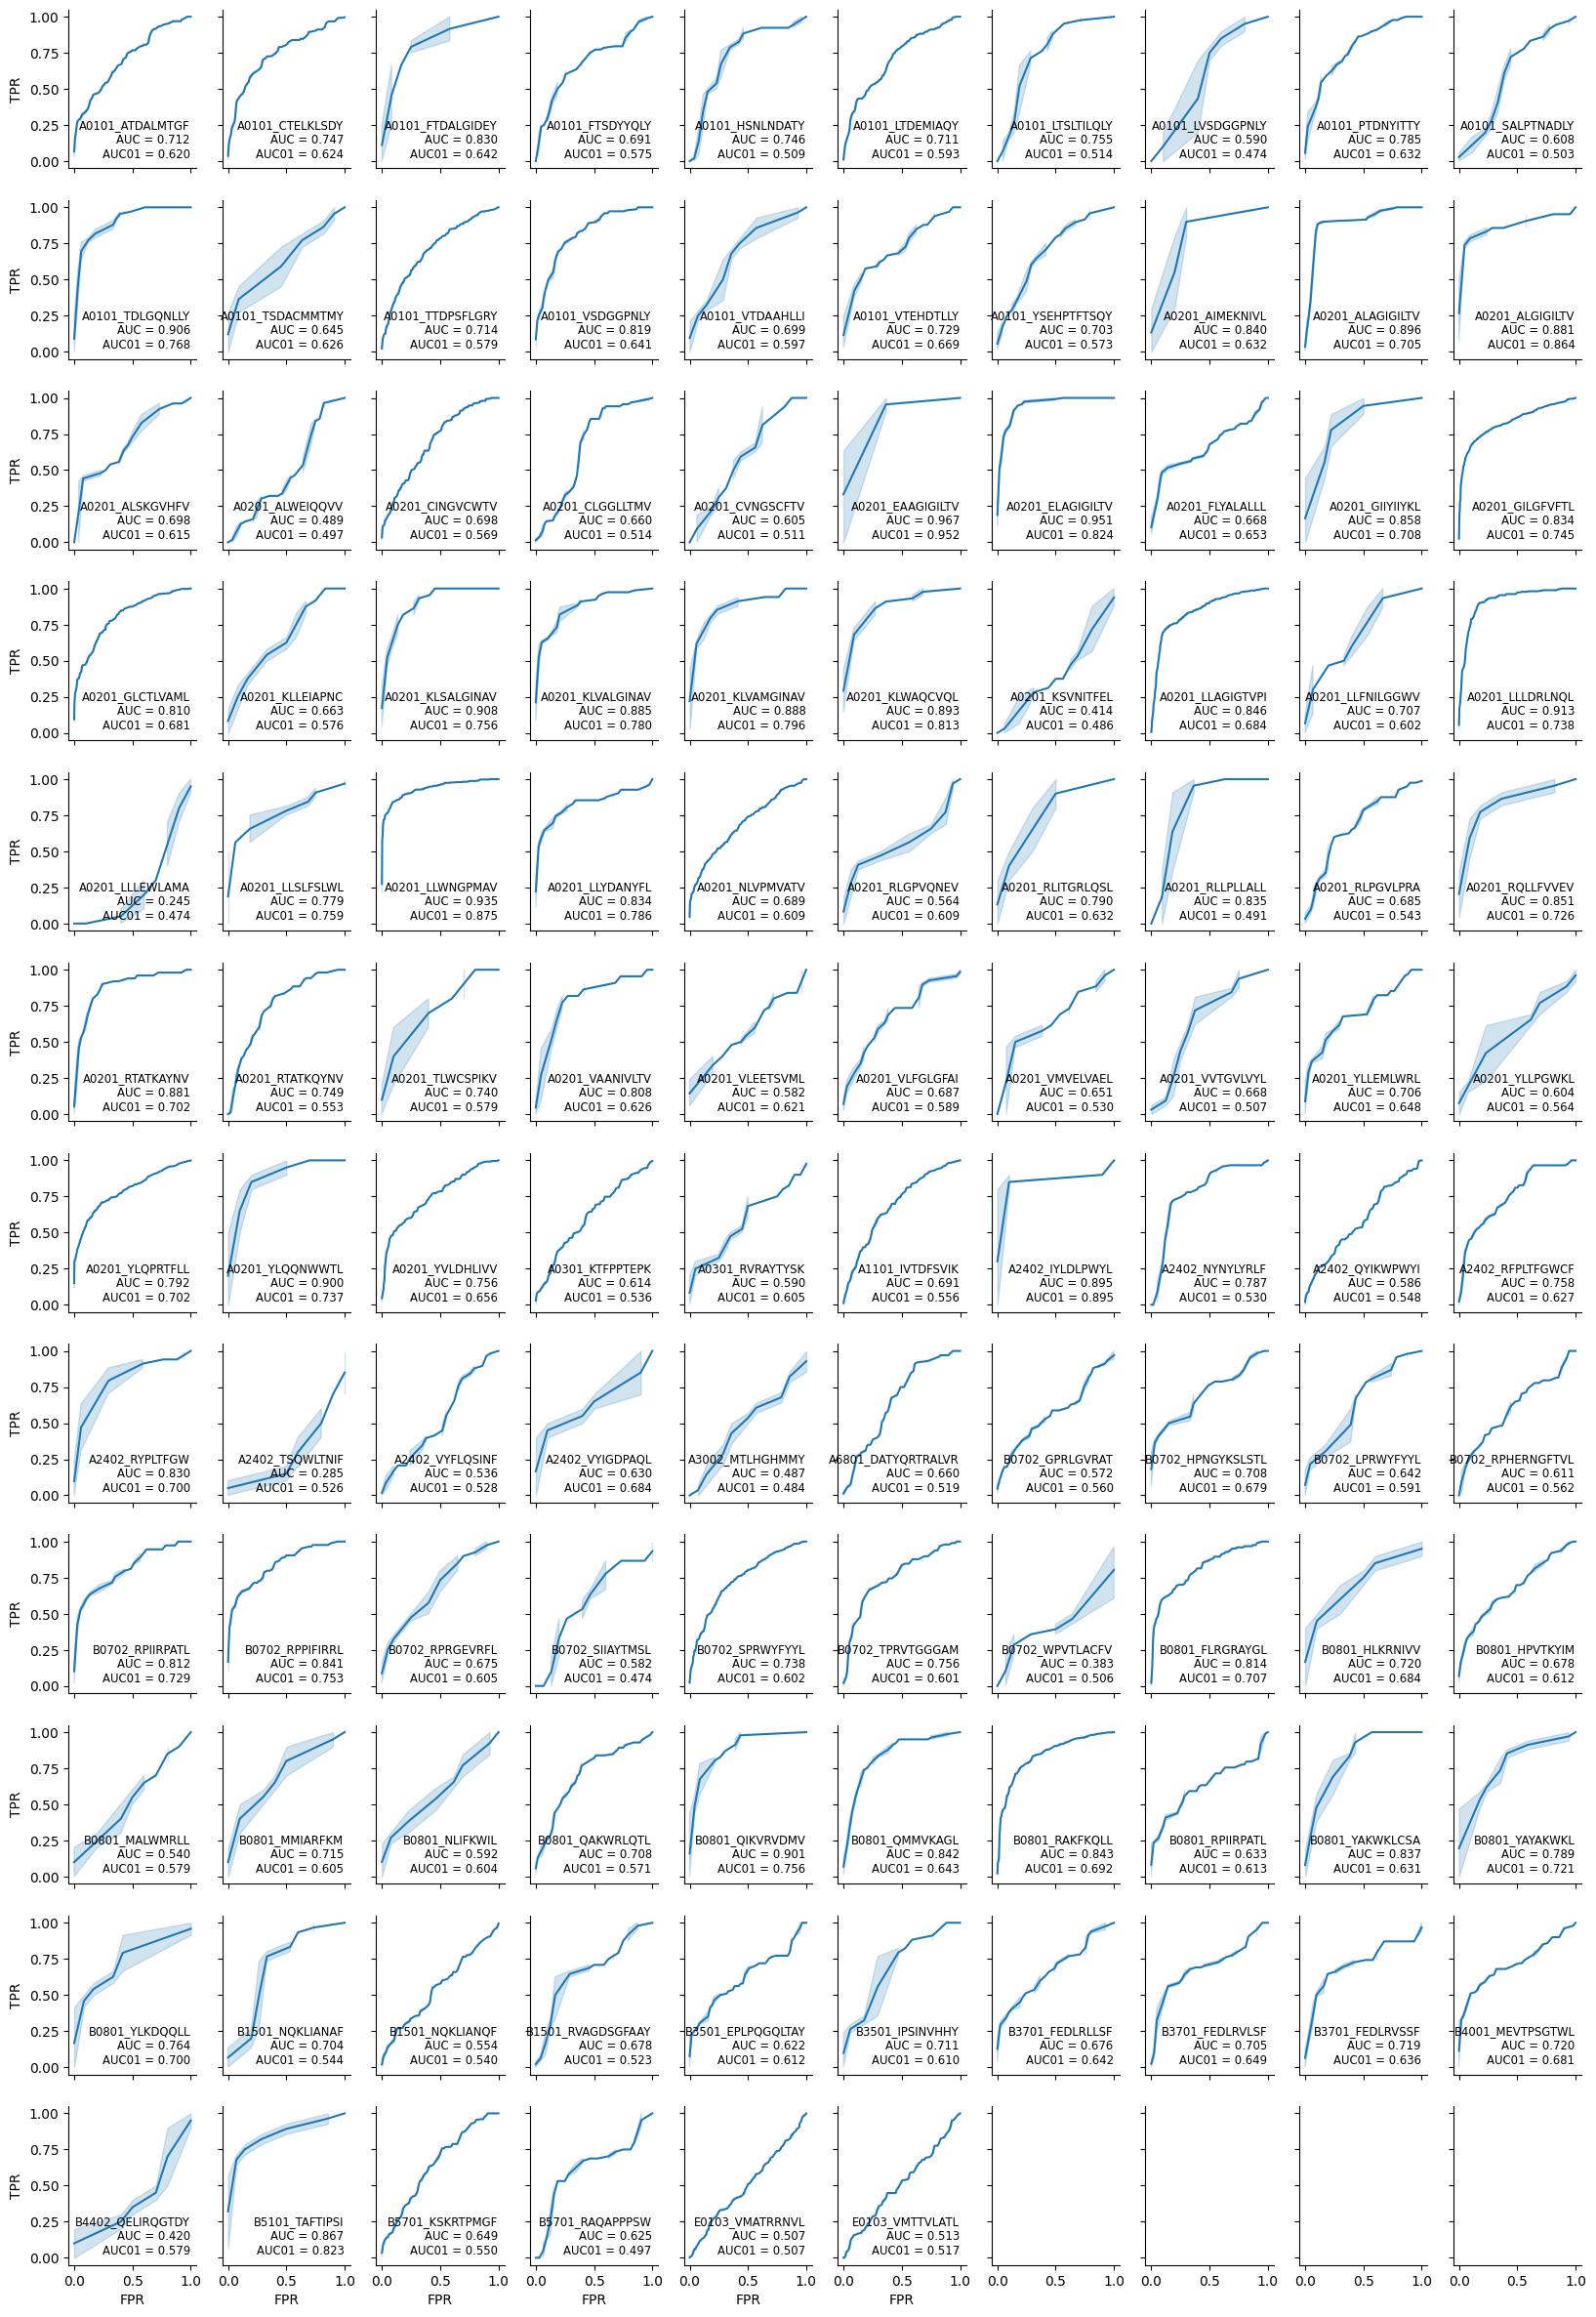

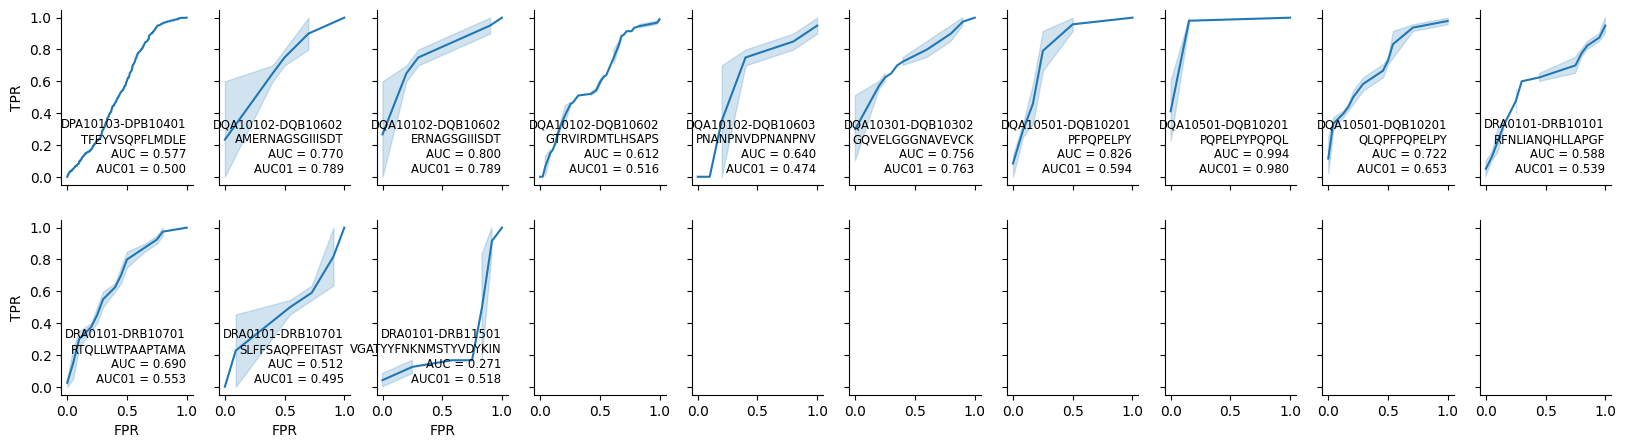

In [3]:
mhcs = ['class_I', 'class_II']
for mhc in mhcs:
    df = pd.read_csv(f'AF3_{mhc}_output.csv')

    if mhc == 'class_I':
        fig, axes = plt.subplots(12, 10, figsize=(20, 30), sharex=True, sharey=True)
    else:
        fig, axes = plt.subplots(2, 10, figsize=(20, 5), sharex=True, sharey=True)

    dico = {
        'epitope': [],
        'n_samples': [],
        'n_samples_iptm_0.5': [],
        'n_samples_iptm_0.8': [],
        'auc': [],
        'auc01': [],
    }

    for cnt, (name, group) in enumerate(df.groupby('epitope')):
        row = cnt // 10
        col = cnt % 10
        ax = axes[row, col]

        scores_pos = group.loc[group['batch'] == 'positives', 'AF3_iptm_pair_mean'].values
        scores_neg = group.loc[group['batch'] == 'negatives', 'AF3_iptm_pair_mean'].values

        # skip invalid cases
        if len(scores_pos) == 0 or len(scores_neg) == 0:
            continue

        # labels + scores
        y_true = np.concatenate([
            np.ones(len(scores_pos)),
            np.zeros(len(scores_neg))
        ])
        y_scores = np.concatenate([scores_pos, scores_neg])

        # ROC + metrics
        fpr, tpr, _ = roc_curve(y_true, y_scores)
        auc_full = roc_auc_score(y_true, y_scores)
        auc01 = roc_auc_score(y_true, y_scores, max_fpr=0.1)  # standardized AUC01

        # plot
        sns.lineplot(x=fpr, y=tpr, ax=ax)

        if mhc == 'class_I':
            label = f"{name}\nAUC = {auc_full:.3f}\nAUC01 = {auc01:.3f}"
        else:
            mhc_peptide = name.split('_')
            label = f"{mhc_peptide[0]}\n{mhc_peptide[1]}\nAUC = {auc_full:.3f}\nAUC01 = {auc01:.3f}"

        ax.text(
            0.95, 0.05,
            label,
            transform=ax.transAxes,
            ha='right',
            va='bottom',
            fontsize='small'
        )

        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        sns.despine()

        # store results
        dico['epitope'].append(name)
        dico['n_samples'].append(len(scores_pos))
        dico['n_samples_iptm_0.5'].append((scores_pos > 0.5).sum())
        dico['n_samples_iptm_0.8'].append((scores_pos > 0.8).sum())
        dico['auc'].append(auc_full)
        dico['auc01'].append(auc01)

    # save results
    df_auc = pd.DataFrame(dico)
    df_auc.to_csv(f'AF3_{mhc}_auc.csv', index=False)
    print(df_auc.head())

10
10
10
10
10
10


/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_61677/210889726.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=90)
/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_61677/210889726.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=90)
/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_61677/210889726.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=90)


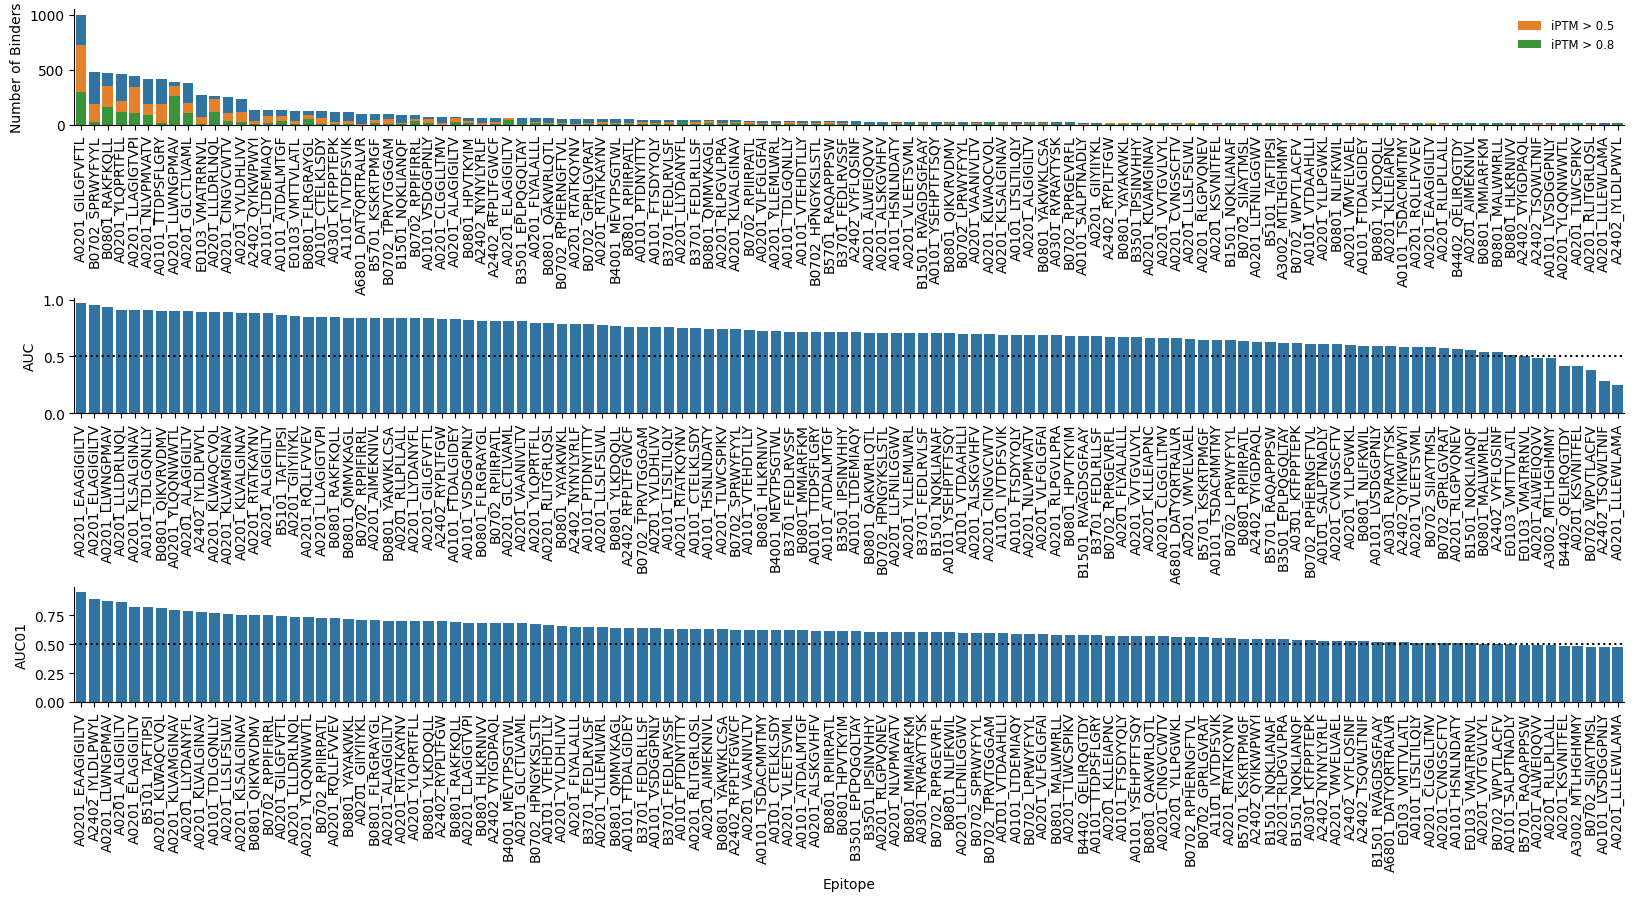

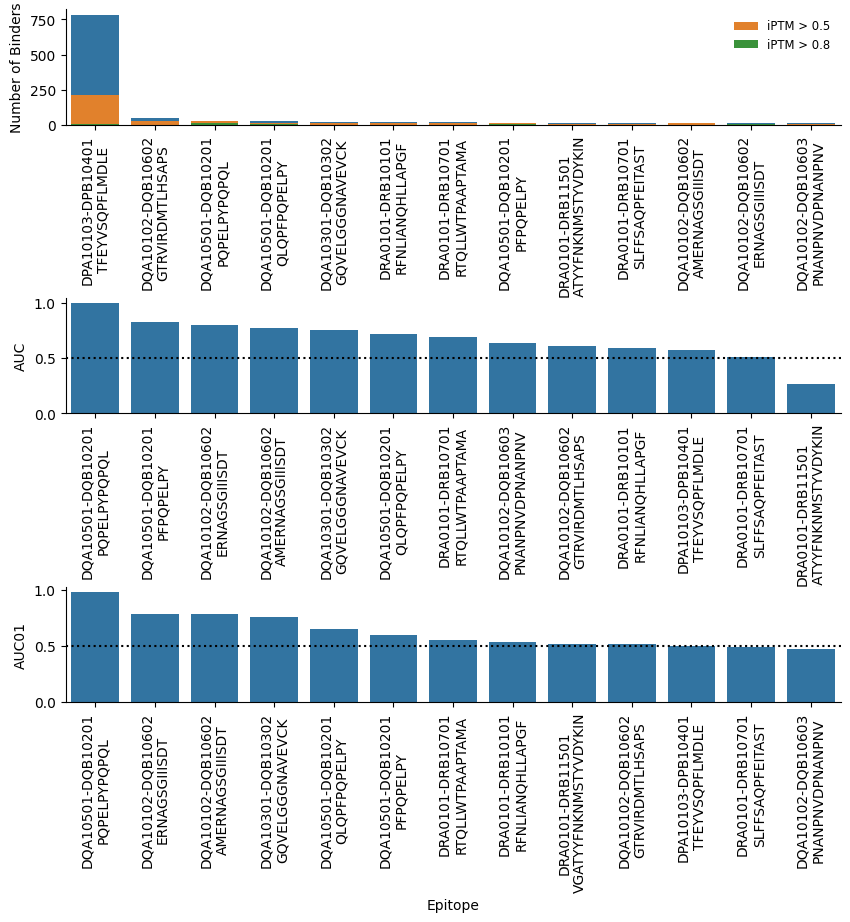

In [4]:
mhcs = ['class_I', 'class_II']
for mhc in mhcs:
    df = pd.read_csv(f'AF3_{mhc}_auc.csv')

    
    if mhc == 'class_I':
        fig, axes = plt.subplots(3, 1, figsize=(20,9))
        fig.subplots_adjust(hspace=1.5)
    else:
        fig, axes = plt.subplots(3, 1, figsize=(10,9))
        fig.subplots_adjust(hspace=1.5)

    df = df.sort_values(by='n_samples', ascending=False)
    sns.barplot(df, x='epitope', y='n_samples', ax=axes[0])
    sns.barplot(df, x='epitope', y='n_samples_iptm_0.5', ax=axes[0], label = 'iPTM > 0.5')
    sns.barplot(df, x='epitope', y='n_samples_iptm_0.8', ax=axes[0], label = 'iPTM > 0.8')
    axes[0].tick_params(axis='x', rotation=90)
    print(np.min(df['n_samples']))
    axes[0].set_xlabel('Epitope')
    axes[0].set_ylabel('Number of Binders')
    axes[0].legend(frameon=False, fontsize='small')

    df = df.sort_values(by='auc', ascending=False)
    sns.barplot(df, x='epitope', y='auc', ax=axes[1])
    axes[1].tick_params(axis='x', rotation=90)
    print(np.min(df['n_samples']))
    axes[1].set_xlabel('Epitope')
    axes[1].set_ylabel('AUC')
    axes[1].axhline(0.5, color='black', linestyle=':')

    df = df.sort_values(by='auc01', ascending=False)
    sns.barplot(df, x='epitope', y='auc01', ax=axes[2])
    axes[2].tick_params(axis='x', rotation=90)
    print(np.min(df['n_samples']))
    axes[2].set_xlabel('Epitope')
    axes[2].set_ylabel('AUC01')
    axes[2].axhline(0.5, color='black', linestyle=':')

    if mhc == 'class_II':
        for ax in axes:
            labels = [tick.get_text() for tick in ax.get_xticklabels()]
            new_labels = [lbl.replace("_", "\n") for lbl in labels]
            ax.set_xticklabels(new_labels, rotation=90)

    sns.despine()

             epitope  n_samples  n_samples_iptm_0.5  n_samples_iptm_0.8  \
25  A0201_EAAGIGILTV         11                  10                   9   
26  A0201_ELAGIGILTV         57                  56                  38   
42   A0201_LLWNGPMAV        388                 348                 258   
39   A0201_LLLDRLNQL        261                 236                 111   
32  A0201_KLSALGINAV         22                  13                   9   

         auc     auc01  
25  0.966942  0.952153  
26  0.951062  0.823589  
42  0.935315  0.874991  
39  0.912850  0.737928  
32  0.908058  0.756416  
                             epitope  n_samples  n_samples_iptm_0.5  \
7     DQA10501-DQB10201_PQPELPYPQPQL         26                  26   
6        DQA10501-DQB10201_PFPQPELPY         12                  11   
2    DQA10102-DQB10602_ERNAGSGIIISDT         10                   8   
1  DQA10102-DQB10602_AMERNAGSGIIISDT         10                   9   
5  DQA10301-DQB10302_GQVELGGGNAVEVCK        

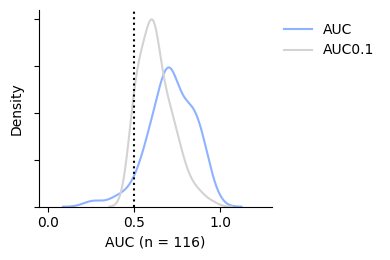

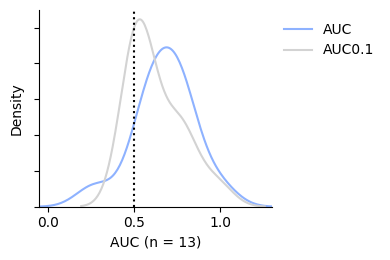

In [5]:
unil_light = sns.color_palette(["#8EB2FF", "lightgrey"])

mhcs = ['class_I', 'class_II']
for mhc in mhcs:
    df = pd.read_csv(f'AF3_{mhc}_auc.csv')
    df = df.sort_values(by='auc', ascending=False)
    print(df.head())

    fig, ax = plt.subplots(1,1, figsize=(4, 2.7), tight_layout=True)

    for cnt, (col, label) in enumerate(zip(['auc', 'auc01'], ['AUC', 'AUC0.1'])):
        sns.kdeplot(df[col].dropna(), ax=ax, label=label, fill=False, color=unil_light[cnt])

    ax.axvline(0.5, color='black', linestyle=':')
    ax.set_xlabel(f'AUC (n = {len(df)})')
    ax.set_ylabel('Density')
    ax.set_yticklabels([])
    ax.legend(frameon=False, bbox_to_anchor=(1,1), loc='upper left')
    ax.set_xlim(-0.05,1.3)

    sns.despine()
    plt.savefig(f'/Users/roessner/Downloads/output_{mhc}.png', dpi=500)

In [28]:
df = pd.read_csv(f'AF3_class_I_auc.csv')
df = df[df['epitope'] == 'A0201_GILGFVFTL']

df = pd.read_csv(f'AF3_class_II_auc.csv')
df = df[df['epitope'] == 'DPA10103-DPB10401_TFEYVSQPFLMDLE']
df

,epitope,n_samples,n_samples_iptm_0.5,n_samples_iptm_0.8,auc,auc01
0,DPA10103-DPB10401_TFEYVSQPFLMDLE,784,204,8,0.442892,0.481535


# TCR motifs

In [5]:
def extract_cdr_plddt(cif_path, cdr_dict, chain_map={"TRA":"TCRA","TRB":"TCRB"}, epitope_chains=["MHC","PEPTIDE"]):
    """
    Extract plddt of CDRs based on the respective sequences.
    """

    parser = MMCIFParser(QUIET=True)
    structure = parser.get_structure("cif", cif_path)
    model = structure[0]

    cdr_plddt = {}

    for chain_label, chain_id in chain_map.items():
        chain_obj = model[chain_id]

        residues = [res for res in chain_obj if res.id[0] == " " and "CA" in res]
        seq = "".join(seq1(res.get_resname()) for res in residues)

        cdr_dict_chain = {}
        for key, value in cdr_dict.items():
            if key.endswith(chain_id[-1]):
                cdr_dict_chain[key] = value

        for cdr, cdr_seq in cdr_dict_chain.items():
            L = len(cdr_seq)

            start_idx = seq.find(cdr_seq)
            if start_idx == -1:
                print(f"Warning: {cdr} not found in {chain_id} of {cif_path}")
                continue

            end_idx = start_idx + L

            plddts = []
            for res in residues[start_idx:end_idx]:
                res_plddts = []
                for atom in res.get_atoms():
                    res_plddts.append(atom.get_bfactor())

                mean_res_plddts = np.mean(res_plddts) / 100
                plddts.append(np.round(mean_res_plddts, 2))

            cdr_plddt[cdr] = np.array(plddts) 

    return cdr_plddt

def split_cdr3(cdr3, v_gene, j_gene, v_ref, j_ref):
    """
    Split CDR3 into V, insertion, and J sequences.
    Returns: v_seq_str, insertion_seq_str, j_seq_str
    """
    # Get reference sequences
    v_seq = v_ref.loc[v_ref['Gene']==v_gene, 'CDR3'].values
    j_seq = j_ref.loc[j_ref['Gene']==j_gene, 'CDR3'].values
    
    if len(v_seq)==0 or len(j_seq)==0:
        # If reference is missing, put everything as 'Unknown'
        return None, None
    
    v_seq = v_seq[0]
    j_seq = j_seq[0]
    
    # Match V at the start
    v_len = 0
    for i in range(min(len(v_seq), len(cdr3))):
        if cdr3[i] == v_seq[i]:
            v_len += 1
        else:
            break
    
    # Match J at the end
    j_len = 0
    for i in range(1, min(len(j_seq), len(cdr3))+1):
        if cdr3[-i] == j_seq[-i]:
            j_len += 1
        else:
            break
    
    v_part = cdr3[:v_len]
    j_part = cdr3[len(cdr3)-j_len:] if j_len > 0 else ''
    insertion_part = cdr3[v_len:len(cdr3)-j_len] if len(cdr3) > v_len + j_len else ''
    
    # drop first C and last F/W
    v_part = v_part[1:]
    j_part = j_part[:-1]

    return v_part, j_part

In [ ]:
af3_input = pd.read_csv('class_I/positives/AF3_class_I_input.txt', sep='\t')[['id', 'cdr3_TRA', 'cdr3_TRB', 'TRAV', 'TRAJ', 'TRBV', 'TRBJ']]
af3_output = pd.read_csv('class_I/positives/AF3_class_I_output.txt', sep='\t')[['id', 'AF3_iptm_pair_mean']]
df = pd.merge(af3_input, af3_output)
df = df.dropna()
df.to_csv(f"AF3_class_I_baseline.txt", sep="\t", index=False)

df = df[df['AF3_iptm_pair_mean'] > 0.8]
df = df.rename(columns={'epitope':'model'})
df.to_csv(f"AF3_class_I_motif.txt", sep="\t", index=False)
print(len())

,id,cdr3_TRA,cdr3_TRB,TRAV,TRAJ,TRBV,TRBJ,AF3_iptm_pair_mean
3,tcr_00004,CAVSAGDYKLSF,CATSDSVAGNQPQHF,TRAV8-4,TRAJ20,TRBV24-1,TRBJ1-5,0.8825
7,tcr_00008,CLPSGTYKYIF,CASSFMGQLDEQFF,TRAV4,TRAJ40,TRBV7-9,TRBJ2-1,0.8175
10,tcr_00011,CAMWGAQKLVF,CASSFVKLADSSYNEQFF,TRAV12-3,TRAJ54,TRBV28,TRBJ2-1,0.8675
12,tcr_00013,CATHPSGTYKYIF,CAISESAEAYEQYF,TRAV17,TRAJ40,TRBV10-3,TRBJ2-7,0.8500
15,tcr_00016,CAYRSLYGGSQGNLIF,CASSQERNSNQPQHF,TRAV38-2/DV8,TRAJ42,TRBV4-1,TRBJ1-5,0.8200
...,...,...,...,...,...,...,...,...
9324,tcr_10273,CAESWAGAGSYQLTF,CASSLMGVKGGLFF,TRAV13-2,TRAJ28,TRBV5-1,TRBJ1-4,0.8425
9358,tcr_10307,CAAFTGTASKLTF,CATSRERGGYNEQFF,TRAV29/DV5,TRAJ44,TRBV15,TRBJ2-1,0.8075
9363,tcr_10312,CAVLGVRDYKLSF,CASSQGFAYGYTF,TRAV22,TRAJ20,TRBV14,TRBJ1-2,0.8025
9365,tcr_10314,CAENSGGGADGLTF,CASSPGGNTEAFF,TRAV13-2,TRAJ45,TRBV4-1,TRBJ1-1,0.8400


In [ ]:
# plddt annotation
df = pd.read_csv(f'AF3_class_I_motif.txt', delim_whitespace=True)

df = df.rename(columns={'cdr3_TRA' : 'CDR3A', 'cdr3_TRB' : 'CDR3B'})

genes = ['TRAV', 'TRBV']
for gene in genes:
    anno = pd.read_csv(f'../MixTCRviz/data_raw/HomoSapiens/{gene}.csv')
    anno = anno.rename(columns={anno.columns[0]:gene})

    anno[f'CDR1{gene[-2]}'] = anno['CDR1'].str.replace('-', '', regex=False)
    anno[f'CDR2{gene[-2]}'] = anno['CDR2'].str.replace('-', '', regex=False)
    anno = anno[[gene, f'CDR1{gene[-2]}', f'CDR2{gene[-2]}']]

    df = pd.merge(df, anno, on=gene)

# reference dataframes to split cdr3 according to V/J contributions
TRAV_ref = pd.read_csv(f'../MixTCRviz/data_raw/HomoSapiens/TRAV.csv').rename(columns={'Unnamed: 0':'Gene'})
TRAJ_ref = pd.read_csv(f'../MixTCRviz/data_raw/HomoSapiens/TRAJ.csv').rename(columns={'Unnamed: 0':'Gene'})
TRBV_ref = pd.read_csv(f'../MixTCRviz/data_raw/HomoSapiens/TRBV.csv').rename(columns={'Unnamed: 0':'Gene'})
TRBJ_ref = pd.read_csv(f'../MixTCRviz/data_raw/HomoSapiens/TRBJ.csv').rename(columns={'Unnamed: 0':'Gene'})

lst = []
for idx, row in df.iterrows():
    cdr_dict = {cdr: str(row[cdr]).upper() for cdr in ["CDR1A","CDR2A","CDR3A","CDR1B","CDR2B","CDR3B"]}

    file = f'/Volumes/LaCie/260330_af3_benchmark/class_I/positives/AF3_outputs/{row.id}/{row.id}_model.cif'
    
    cdr_plddts = extract_cdr_plddt(file, cdr_dict, chain_map={"TRA":"TCRA","TRB":"TCRB"}, epitope_chains=["MHC","PEPTIDE"])

    # add cdr3 v/j part
    v_part, j_part = split_cdr3(row.CDR3A, row.TRAV, row.TRAJ, TRAV_ref, TRAJ_ref)
    cdr_plddts['CDR3AV'] = cdr_plddts['CDR3A'][:len(v_part)]
    cdr_plddts['CDR3AJ'] = cdr_plddts['CDR3A'][-len(j_part):]

    v_part, j_part = split_cdr3(row.CDR3B, row.TRBV, row.TRBJ, TRBV_ref, TRBJ_ref)
    cdr_plddts['CDR3BV'] = cdr_plddts['CDR3B'][:len(v_part)]
    cdr_plddts['CDR3BJ'] = cdr_plddts['CDR3B'][-len(j_part):]

    cdr_plddts['id'] = row.id
    cdr_plddts['TRAV'] = row.TRAV
    cdr_plddts['TRAJ'] = row.TRAJ
    cdr_plddts['TRBV'] = row.TRBV
    cdr_plddts['TRBJ'] = row.TRBJ
    cdr_plddts['CDR3A_seq'] = row.CDR3A
    cdr_plddts['CDR3B_seq'] = row.CDR3B
    lst.append(cdr_plddts)

df = pd.DataFrame(lst)   
df.to_csv(f'AF3_class_I_cdr_plddts.csv', index=False)

# Peptide Length

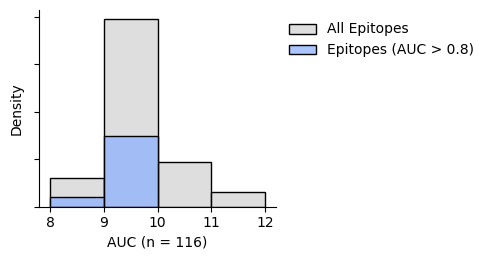

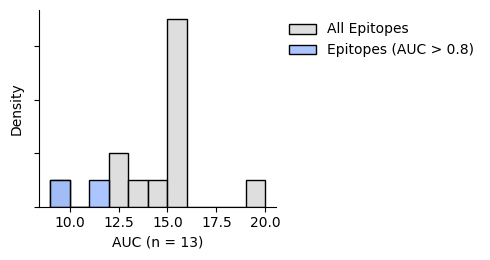

In [6]:
unil_light = sns.color_palette(["#8EB2FF", "lightgrey"])

mhcs = ['class_I', 'class_II']
for mhc in mhcs:
    df = pd.read_csv(f'AF3_{mhc}_auc.csv')
    fig, ax = plt.subplots(1,1, figsize=(5, 2.7), tight_layout=True)

    df['peptide'] = df['epitope'].str.split('_').str[1]
    df['len_peptide'] = df['peptide'].str.len()

    sns.histplot(df, x='len_peptide', ax=ax, label='All Epitopes', color=unil_light[1], binwidth=1)

    df_auc = df[df['auc'] > 0.8]
    sns.histplot(df_auc, x='len_peptide', ax=ax, label='Epitopes (AUC > 0.8)', color=unil_light[0], binwidth=1)


    ax.set_xlabel(f'AUC (n = {len(df)})')
    ax.set_ylabel('Density')
    ax.set_yticklabels([])
    ax.legend(frameon=False, bbox_to_anchor=(1,1), loc='upper left')

    sns.despine()
    plt.savefig(f'/Users/roessner/Downloads/output_{mhc}.png', dpi=500)

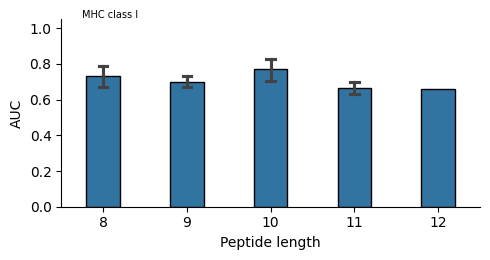

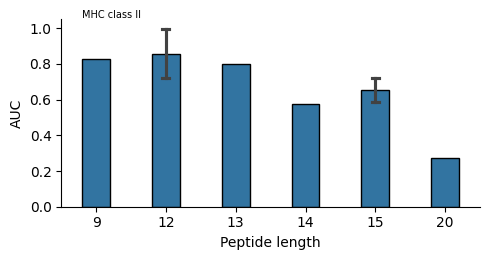

In [7]:
mhcs = ['class_I', 'class_II']
for mhc in mhcs:
    df = pd.read_csv(f'AF3_{mhc}_auc.csv')
    fig, ax = plt.subplots(1,1, figsize=(5, 2.7), tight_layout=True)

    df['peptide'] = df['epitope'].str.split('_').str[1]
    df['len_peptide'] = df['peptide'].str.len()

    sns.barplot(data=df, x='len_peptide', y='auc', ax=ax, capsize=0.1, gap=0.5, edgecolor='black')

    ax.set_xlabel('Peptide length')
    ax.set_ylabel('AUC')
    
    sns.despine()

    if mhc == 'class_I':
        text = 'MHC class I'
    else:
        text = 'MHC class II'

    ax.text(
    0.05, 1.05, text, 
    transform=ax.transAxes, fontsize=7, verticalalignment='top'
    )

    ax.set_ylim(0,1.05)


/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_61677/3272270106.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_61677/3272270106.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


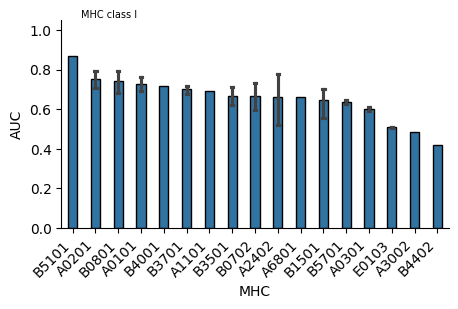

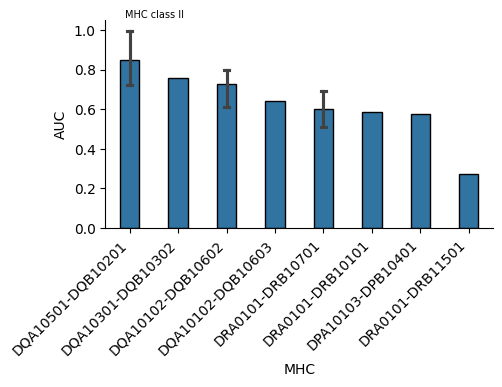

In [8]:
mhcs = ['class_I', 'class_II']
for mhc in mhcs:
    df = pd.read_csv(f'AF3_{mhc}_auc.csv')
    df = df.sort_values(by='auc', ascending=False)
    fig, ax = plt.subplots(1,1, figsize=(5, 2.7))

    df['MHC'] = df['epitope'].str.split('_').str[0]

    mhc_order = df.groupby('MHC')['auc'].mean().sort_values(ascending=False).index

    sns.barplot(data=df, x='MHC', y='auc', order=mhc_order, ax=ax, capsize=0.1, gap=0.5, edgecolor='black')

    ax.set_xlabel('MHC')
    ax.set_ylabel('AUC')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    
    sns.despine()

    text = 'MHC class I' if mhc == 'class_I' else 'MHC class II'

    ax.text(
        0.05, 1.05, text, 
        transform=ax.transAxes, fontsize=7, verticalalignment='top'
    )

    ax.set_ylim(0, 1.05)